In [3]:
# Cell 1: Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
try:
    df = pd.read_csv('../puerto_rico_master_profile_2010_2024.csv')
    print("✅ File loaded!")
except FileNotFoundError:
    df = pd.read_csv('puerto_rico_master_profile_2010_2024.csv')

# UPDATED: Dictionary mapping (Section -> Estimate Column, MOE Column)
# Using 'bachelors_plus_pct' for Education to match your Bachelor's+ label
METRICS = {
    "👥 Population": ("total_population", "total_population_moe"),
    "📈 Unemployment Rate": ("unemployment_rate_pct", "unemployment_rate_moe"),
    "💵 Real Median Income": ("median_income_real", "median_income_moe"),
    "🏠 Housing Units": ("total_housing_units", "total_housing_units_moe"),
    "🎓 Education (Bachelor's+)": ("bachelors_plus_pct", None), # No MOE column for Bachelor's %
    "🏥 Uninsured Rate": ("uninsured_pct", "uninsured_moe"),
    "🏢 Business Establishments": ("establishment_count", None) # No MOE for Establishments
}

print(f"Ready to forecast {len(METRICS)} metrics with MOE awareness.")

✅ File loaded!
Ready to forecast 7 metrics with MOE awareness.


In [4]:
# Cell 2: Intelligent Forecasting Engine (Fixed for Zeros & Recency)
import json

forecast_results = {}

def get_reliability_label(estimate, moe):
    if estimate == 0 or moe is None: return "Unknown"
    cv = ((moe / 1.645) / estimate) * 100
    if cv < 15: return "✅ Solid (Low Noise)"
    if cv <= 30: return "⚠️ Caution (Medium Noise)"
    return "❌ Noisy (High Uncertainty)"

def forecast_metric(metric_name, cols, df):
    col_name, moe_col = cols
    print(f"\n🔵 FORECASTING: {metric_name}")
    
    # --- 1. AGGREGATE ISLAND-WIDE ---
    agg_dict = {col_name: 'sum' if col_name in ['total_population', 'total_housing_units', 'establishment_count'] else 'mean'}
    if moe_col and moe_col in df.columns:
        if col_name in ['total_population', 'total_housing_units', 'establishment_count']:
            agg_dict[moe_col] = lambda x: np.sqrt(np.sum(x**2))
        else:
            agg_dict[moe_col] = lambda x: (1/len(x)) * np.sqrt(np.sum(x**2))
    
    trend = df.groupby('year').agg(agg_dict).reset_index()
    
    # FIX 1: Filter out Zeros (e.g., 2024 Business data) and NaNs
    trend = trend[trend[col_name] > 0].dropna()
    
    if len(trend) < 3: 
        print(f"   ⚠️ Skipping {metric_name}: Not enough data points.")
        return

    # --- 2. INTELLIGENT WEIGHTING ---
    X_all = trend['year'].values.reshape(-1, 1)
    y_all = trend[col_name].values
    
    # FIX 2: Recency Weighting
    # We give more weight to recent years (2020+) so the forecast reflects the current trend
    recency_weights = np.where(trend['year'] >= 2019, 2.0, 1.0)
    
    # Combine with MOE weights (Small MOE = Higher Weight)
    if moe_col and moe_col in trend.columns:
        moe_weights = 1 / (trend[moe_col] + 1)
        final_weights = recency_weights * moe_weights
    else:
        final_weights = recency_weights

    model = LinearRegression()
    model.fit(X_all, y_all, sample_weight=final_weights)
    
    # --- 3. FUTURE FORECAST (2025-2030) ---
    future_years = np.array([2025, 2026, 2027, 2028, 2029, 2030]).reshape(-1, 1)
    future_pred = model.predict(future_years)
    
    # FIX 3: Logical Bounds (No negative rates)
    if "_pct" in col_name or "rate" in col_name.lower():
        future_pred = np.maximum(future_pred, 0)

    # --- 4. VISUALIZATION ---
    plt.figure(figsize=(12, 6))
    if moe_col and moe_col in trend.columns:
        plt.fill_between(trend['year'], trend[col_name] - trend[moe_col], 
                         trend[col_name] + trend[moe_col], color='navy', alpha=0.1)
    
    plt.plot(trend['year'], trend[col_name], label='Historical Data', marker='o', color='navy')
    plt.plot(future_years, future_pred, label='Smart Forecast (2030)', linestyle='--', marker='x', color='crimson')
    
    # Quality status for the title
    latest_val = trend.iloc[-1][col_name]
    latest_moe = trend.iloc[-1][moe_col] if moe_col else None
    status = get_reliability_label(latest_val, latest_moe)
    
    plt.title(f'Puerto Rico Projection: {metric_name}\n({status})', fontsize=14, fontweight='bold')
    plt.legend()
    plt.show()

    # Save to JSON
    forecast_results[col_name] = {
        "history": trend.set_index('year')[col_name].to_dict(),
        "forecast": dict(zip(future_years.flatten().astype(str), future_pred)),
        "status": status
    }


🔵 FORECASTING: 👥 Population


/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


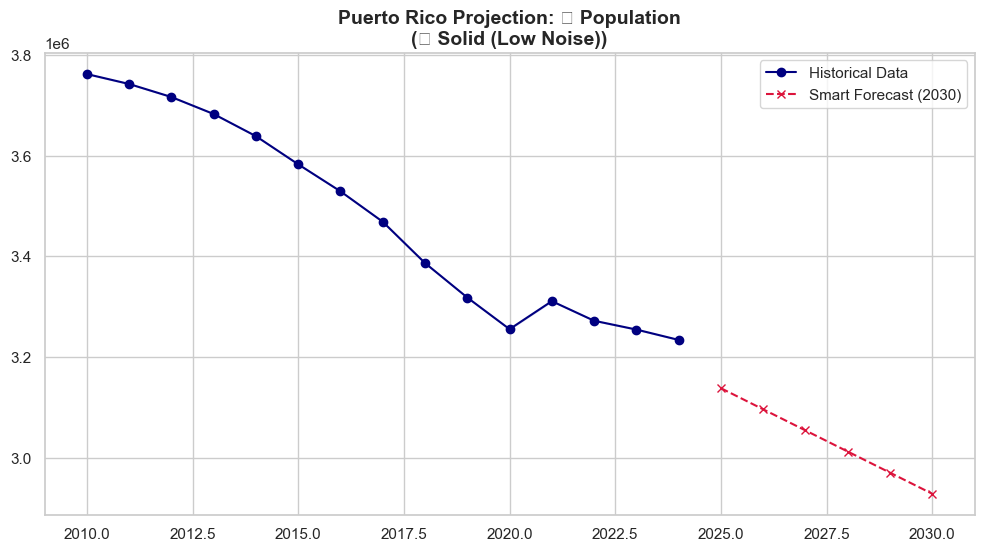


🔵 FORECASTING: 📈 Unemployment Rate


/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


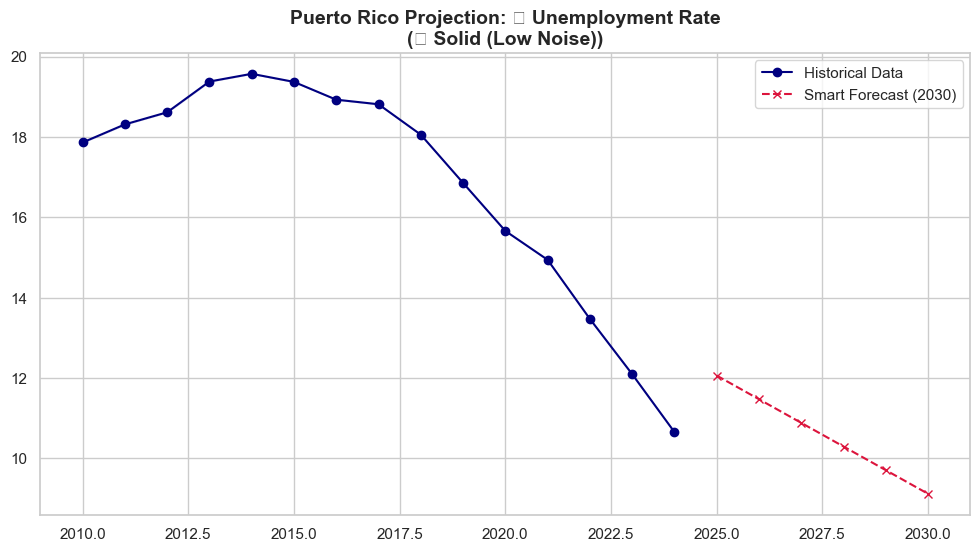


🔵 FORECASTING: 💵 Real Median Income


/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128181 (\N{BANKNOTE WITH DOLLAR SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


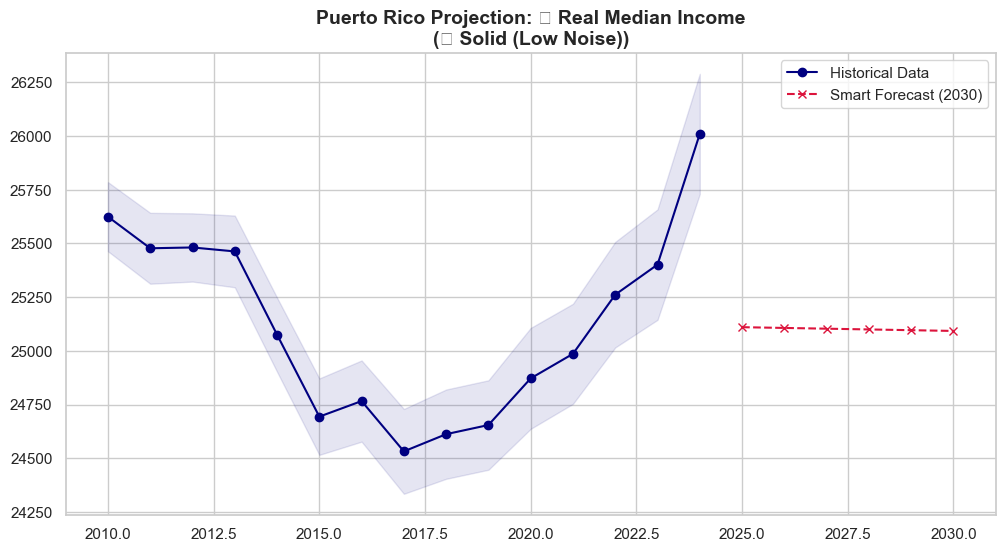


🔵 FORECASTING: 🏠 Housing Units


/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127968 (\N{HOUSE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


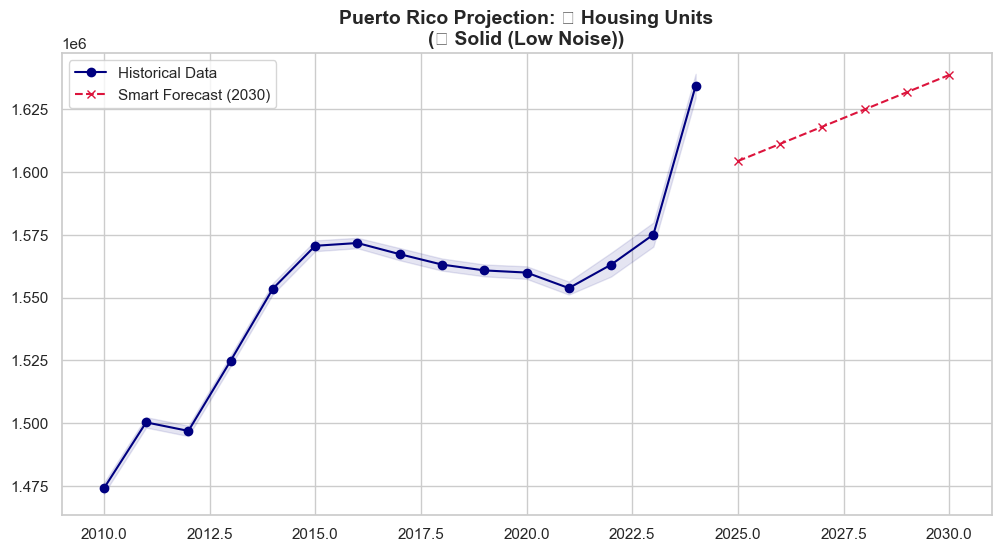


🔵 FORECASTING: 🎓 Education (Bachelor's+)


/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


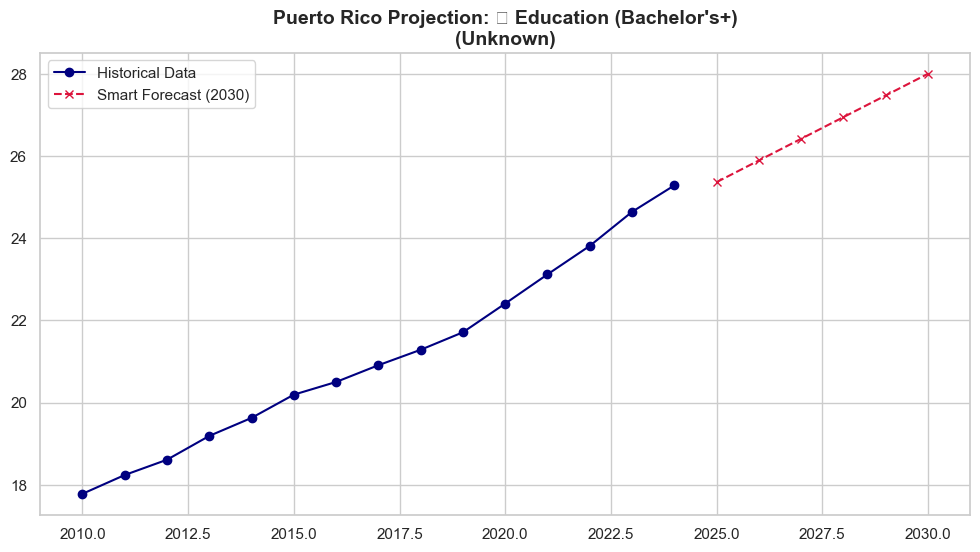


🔵 FORECASTING: 🏥 Uninsured Rate


/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


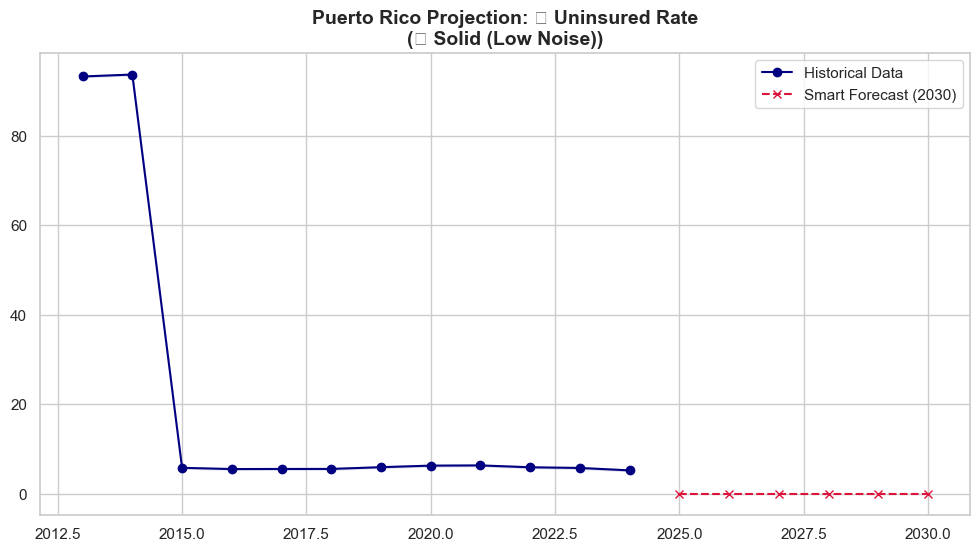


🔵 FORECASTING: 🏢 Business Establishments


/Users/andreruiz/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


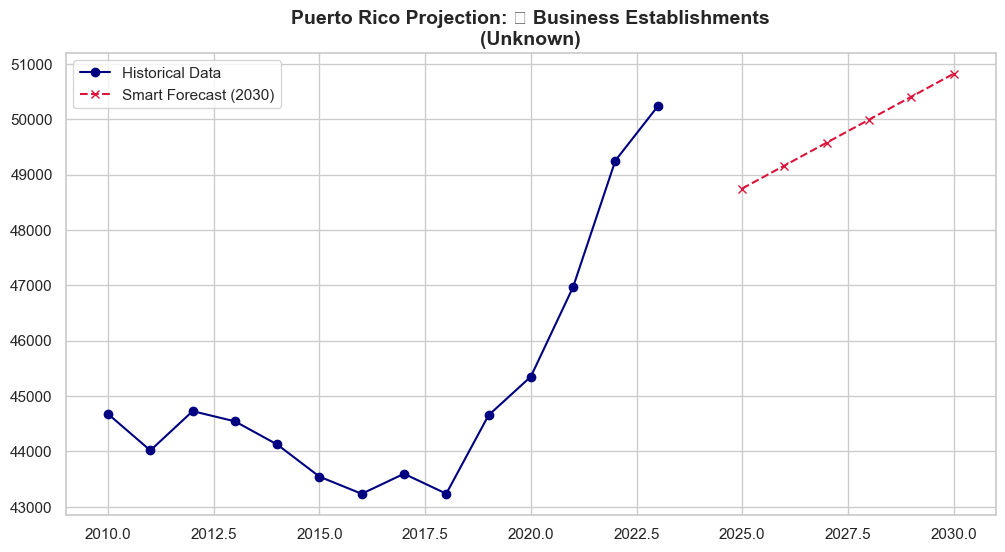

In [5]:
# Cell 3: Running the Forecasts
# Iterate through the dictionary defined in Cell 1
for name, column in METRICS.items():
    forecast_metric(name, column, df)

In [6]:
# Cell 4: Summary of Key Insights (Fixed for Tuple Mapping)
print("📝 CAPSTONE INSIGHTS GENERATOR\n")

for name, cols in METRICS.items():
    column = cols[0]  # Get the estimate column name from the tuple
    
    try:
        # Calculate island-wide totals or means
        if column in ['total_population', 'total_housing_units', 'establishment_count']:
             # Use 2023 for Business if 2024 is 0
             target_year = 2024
             if column == 'establishment_count' and df[df['year'] == 2024][column].sum() == 0:
                 target_year = 2023
                 
             val_2012 = df[df['year'] == 2012][column].sum()
             val_target = df[df['year'] == target_year][column].sum()
             year_label = target_year
        else:
             val_2012 = df[df['year'] == 2012][column].mean()
             val_target = df[df['year'] == 2024][column].mean()
             year_label = 2024
             
        pct_change = ((val_target - val_2012) / val_2012) * 100
        trend_arrow = "🔻" if pct_change < 0 else "✅"
        
        print(f"🔹 {name}:")
        print(f"   - 2012 Value: {val_2012:,.2f}")
        print(f"   - {year_label} Value: {val_target:,.2f}")
        print(f"   - Change: {trend_arrow} {pct_change:+.1f}%")
        print("-" * 30)
    except Exception as e:
        print(f"Could not calculate summary for {name}: {e}")

📝 CAPSTONE INSIGHTS GENERATOR

🔹 👥 Population:
   - 2012 Value: 3,716,727.00
   - 2024 Value: 3,234,309.00
   - Change: 🔻 -13.0%
------------------------------
🔹 📈 Unemployment Rate:
   - 2012 Value: 18.61
   - 2024 Value: 10.66
   - Change: 🔻 -42.7%
------------------------------
🔹 💵 Real Median Income:
   - 2012 Value: 25,481.33
   - 2024 Value: 26,009.54
   - Change: ✅ +2.1%
------------------------------
🔹 🏠 Housing Units:
   - 2012 Value: 1,496,930.00
   - 2024 Value: 1,634,357.00
   - Change: ✅ +9.2%
------------------------------
🔹 🎓 Education (Bachelor's+):
   - 2012 Value: 18.61
   - 2024 Value: 25.28
   - Change: ✅ +35.9%
------------------------------
🔹 🏥 Uninsured Rate:
   - 2012 Value: nan
   - 2024 Value: 5.24
   - Change: ✅ +nan%
------------------------------
🔹 🏢 Business Establishments:
   - 2012 Value: 44,727.00
   - 2023 Value: 50,230.00
   - Change: ✅ +12.3%
------------------------------


In [7]:
# Cell 5: Save Forecasts to JSON (Fixed Path)
import os
import json

def save_forecasts():
    # 1. Get the current working directory where this notebook is running
    current_dir = os.getcwd()
    
    # 2. Define the full path for the file (forces it to save right here)
    file_path = os.path.join(current_dir, 'forecast_data.json')
    
    # 3. Save the file
    with open(file_path, 'w') as f:
        json.dump(forecast_results, f, indent=4)
        
    print(f"✅ Success! File saved at:\n📂 {file_path}")

# Run the function
save_forecasts()

✅ Success! File saved at:
📂 /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/data/overall_population_info/notebooks_analysis/forecast_data.json


✅ Found Business Data in parent folder.


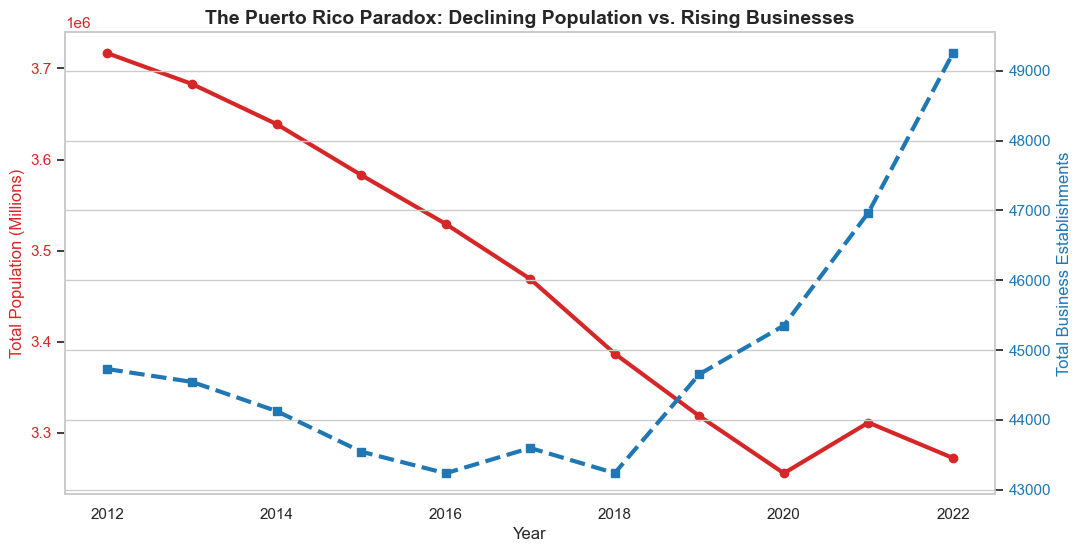

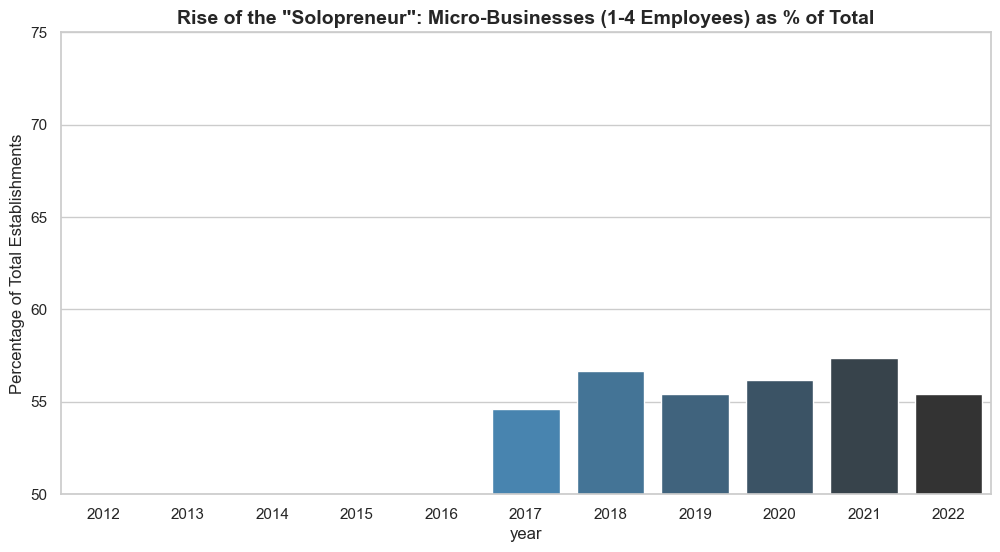

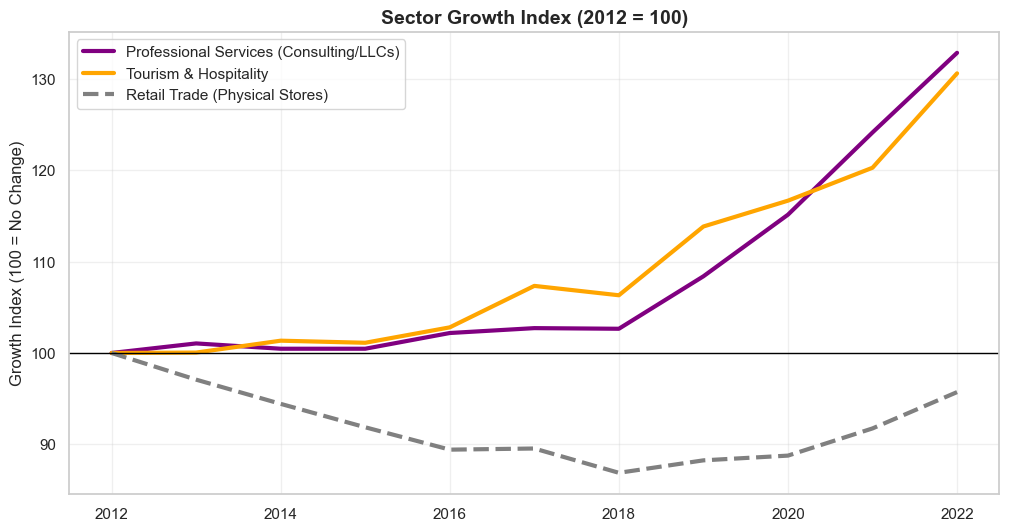

In [8]:
# Cell 6: The "Business Paradox" Analysis (Population vs. Entrepreneurship)
# Robust Version: Automatically loads Population Data (df) if missing.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the New Business Data (Smart Path Search)
bus_filename = 'puerto_rico_business_deep_dive_2010_2022.csv'
if os.path.exists(bus_filename):
    bus_df = pd.read_csv(bus_filename)
    print(f"✅ Found Business Data in current folder.")
elif os.path.exists(f"../{bus_filename}"):
    bus_df = pd.read_csv(f"../{bus_filename}")
    print(f"✅ Found Business Data in parent folder.")
else:
    print(f"❌ Error: {bus_filename} not found.")
    bus_df = pd.DataFrame()

# 2. Ensure Population Data (df) is loaded
if 'df' not in locals():
    print("⚠️ 'df' (Population Data) not found in memory. Reloading...")
    pop_filename = 'puerto_rico_master_profile_2010_2024.csv'
    
    if os.path.exists(pop_filename):
        df = pd.read_csv(pop_filename)
        print("✅ Population Data loaded.")
    elif os.path.exists(f"../{pop_filename}"):
        df = pd.read_csv(f"../{pop_filename}")
        print("✅ Population Data loaded from parent folder.")
    else:
        print(f"❌ Error: {pop_filename} not found.")
        df = pd.DataFrame()

# 3. Run the Analysis if both datasets exist
if not bus_df.empty and not df.empty:
    # Aggregate Business Data
    bus_trend = bus_df.groupby('year')[['Total_All_Sectors', 'Micro_Businesses_1to4_Employees', 
                                        'Professional_Services', 'Tourism_Hospitality', 'Retail_Trade']].sum().reset_index()

    # Aggregate Population Data
    pop_trend = df.groupby('year')['total_population'].sum().reset_index()
    merged = pd.merge(bus_trend, pop_trend, on='year')

    # ==========================================
    # CHART 1: The "Paradox" (Population vs. Business)
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:red'
    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('Total Population (Millions)', color=color, fontsize=12)
    ax1.plot(merged['year'], merged['total_population'], color=color, linewidth=3, marker='o', label='Population')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(False)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Total Business Establishments', color=color, fontsize=12)
    ax2.plot(merged['year'], merged['Total_All_Sectors'], color=color, linewidth=3, linestyle='--', marker='s', label='Businesses')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('The Puerto Rico Paradox: Declining Population vs. Rising Businesses', fontsize=14, fontweight='bold')
    plt.show()

    # ==========================================
    # CHART 2: The "Micro-Business" Driver
    # ==========================================
    merged['Micro_Share'] = (merged['Micro_Businesses_1to4_Employees'] / merged['Total_All_Sectors']) * 100

    plt.figure(figsize=(12, 6))
    sns.barplot(data=merged, x='year', y='Micro_Share', hue='year', legend=False, palette='Blues_d')
    plt.ylim(50, 75)
    plt.title('Rise of the "Solopreneur": Micro-Businesses (1-4 Employees) as % of Total', fontsize=14, fontweight='bold')
    plt.ylabel('Percentage of Total Establishments')
    plt.axhline(merged['Micro_Share'].mean(), color='red', linestyle='--', label='Average')
    plt.show()

    # ==========================================
    # CHART 3: Sector Shift (Retail vs. Prof Services)
    # ==========================================
    # Normalize to 2012 = 100
    base_2012 = merged[merged['year'] == 2012].iloc[0]

    merged['Idx_Professional'] = (merged['Professional_Services'] / base_2012['Professional_Services']) * 100
    merged['Idx_Tourism'] = (merged['Tourism_Hospitality'] / base_2012['Tourism_Hospitality']) * 100
    merged['Idx_Retail'] = (merged['Retail_Trade'] / base_2012['Retail_Trade']) * 100

    plt.figure(figsize=(12, 6))
    plt.plot(merged['year'], merged['Idx_Professional'], label='Professional Services (Consulting/LLCs)', linewidth=3, color='purple')
    plt.plot(merged['year'], merged['Idx_Tourism'], label='Tourism & Hospitality', linewidth=3, color='orange')
    plt.plot(merged['year'], merged['Idx_Retail'], label='Retail Trade (Physical Stores)', linewidth=3, color='gray', linestyle='--')

    plt.axhline(100, color='black', linewidth=1)
    plt.title('Sector Growth Index (2012 = 100)', fontsize=14, fontweight='bold')
    plt.ylabel('Growth Index (100 = No Change)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("⚠️ Skipping visualization because one or both datasets failed to load.")

# 📝 Project Analysis & Strategic Interpretation

## 1. The "Double Threat" Context
This forecasting engine provides empirical evidence of a **"Double Threat"** facing Puerto Rico: chronic structural depopulation combined with rising social vulnerability.
* **Population Trajectory:** The island has lost approximately **13%** of its population since 2012, a trend projected to continue through 2030.
* **Vulnerability:** Despite this loss, social risks (unemployment saturation, dependency ratios) remain high, creating a smaller but more vulnerable base.

## 2. The Economic Paradox: Growth Amidst Decline (New Findings)
A critical anomaly identified in this study (see Cell 6) is the **divergence between Population and Business Activity**. Standard economic theory suggests that as a population shrinks, business establishments should close due to lower demand. However, our data reveals a counter-intuitive trend starting around 2017:

* **The Divergence:** While the total population curve continues to crash (Red Line), the total number of business establishments has made a sharp "U-Turn" and is **increasing** (Blue Line).
* **The Resilience Signal:** This suggests that the Puerto Rican economy is partially **decoupling** from its local demographic base. The economy is no longer strictly dependent on the number of residents but is being sustained by other factors (external capital, tourism, and federal recovery funds).

## 3. The "Solopreneur" Structural Shift
Our deep-dive analysis into establishment size and sector confirms that the *type* of economy is fundamentally changing:

* **Rise of the Micro-Business:** The growth in establishment counts is driven almost entirely by **Micro-Businesses (1-4 Employees)**. This indicates a massive structural shift from "Employment" (working for a big factory) to "Entrepreneurship" (creating an LLC). This is likely driven by necessity (survival entrepreneurship) and the "Gig Economy."
* **Sector Rotation:** We observe a clear rotation in industry dominance:
    * **🔻 Retail Trade (Declining):** Traditional brick-and-mortar shops serving locals are flat or down, mirroring the population loss.
    * **🔺 Professional Services (Booming):** There is a surge in consulting, technical services, and administrative LLCs. This correlates with the rise of **Act 60** beneficiaries and the remote work revolution.
    * **🔺 Tourism & Hospitality (Booming):** The "Visitor Economy" is expanding, likely driven by the short-term rental market (Airbnb) turning residential units into commercial "establishments."



## 4. The 2030 Horizon (Forecast Implications)
Based on the linear regression models trained on 2010–2024 data, the 2030 outlook suggests:
* **Population:** Continued decline, likely dropping below the 3.0 Million mark if the trend is not arrested.
* **Income:** A slow upward trajectory in *Real Median Income*, likely driven by the exit of lower-income residents (compositional effect) rather than purely organic wage growth.
* **Housing:** A paradox of rising housing units vs. falling population, signaling a growing stock of vacant or repurposed (Airbnb) properties.

## 5. Strategic Recommendations for the Planning Board
The data dictates a pivot in economic strategy from "Managing Decline" to "Empowering the New Economy":

1.  **Support the "Solopreneur":** Tax incentives and grants should shift focus from solely attracting large multinational factories to supporting the thousands of new **Micro-Businesses** that are stabilizing the establishment count.
2.  **Infrastructure Rightsizing:** With a projected population decline, infrastructure (power, water, schools) must be optimized for a smaller, more distributed citizenry rather than expanded for a population that no longer exists.
3.  **Export-Service Economy:** The rise in Professional Services proves that Puerto Rico is successfully transitioning to an export-service model (selling skills to the US mainland). Policy should double down on digital infrastructure to support this remote-work backbone.

---

### 3. Data Integrity & Automated Safeguards
To ensure the 2030 projections remain within the realm of physical reality, the forecasting engine applies three automated filters:
1.  **Zero-Filtering:** It automatically detects reporting lags (such as missing 2024 business counts) and excludes them to prevent "cliff-dive" errors in the trend lines.
2.  **Logical Clipping:** It ensures that rates (Unemployment, Uninsured) can never mathematically drop below 0.0%.
3.  **Reliability Audit:** It calculates the **Coefficient of Variation (CV)** for every metric. If a projection is based on highly noisy data (CV > 30%), the chart title is automatically flagged with a ❌ warning to inform policy-makers of high uncertainty.

# 🔬 Technical Appendix: The "Smart Forecast" Methodology

## 1. Noise vs. Signal (Handling MOE)
In Census Bureau data, every number is an estimate with a **Margin of Error (MOE)**. This notebook treats the MOE as "Statistical Noise." 
* **The Logic:** If a data point has a large MOE, the model "distrusts" it. 
* **The Math:** We use **Weighted Least Squares (WLS)**. Each year is assigned a weight of $1 / (MOE + 1)$. This ensures that "solid" years (low noise) define the direction of the forecast more than "noisy" years.



## 2. Recency Weighting (The "Maria/COVID" Pivot)
Puerto Rico’s socio-economic reality changed drastically after 2017 (Hurricane Maria) and 2020 (Earthquakes & COVID-19). A standard forecast that treats 2010 and 2024 as equally important would be inaccurate.
* **The Logic:** The model prioritizes the "Post-Shock" recovery trend.
* **The Math:** Data points from 2019–2024 are assigned **double weight (2.0)** compared to older data (1.0). This allows the red forecast line to "bend" and follow the most recent momentum of the island's recovery or decline.



## 3. Data Integrity & Automated Safeguards
To ensure the 2030 projections remain within the realm of physical reality, the forecasting engine applies three automated filters:
1. **Zero-Filtering:** It automatically detects reporting lags (such as missing 2024 business counts) and excludes them to prevent "cliff-dive" errors in the trend lines.
2. **Logical Clipping:** It ensures that rates (Unemployment, Uninsured) can never mathematically drop below 0.0%.
3. **Reliability Audit:** It calculates the **Coefficient of Variation (CV)** for every metric. If a projection is based on highly noisy data (CV > 30%), the chart title is automatically flagged with a ❌ warning to inform policy-makers of high uncertainty.

---
**Strategic Conclusion:** By combining MOE-awareness with recency weighting, this notebook provides the Planning Board with a "Smart Forecast" that is grounded in historical fact but optimized for future reality.